# **OC&C Analytics Data Science & Strategic Thinking Assessment**

## **Introduction**

### *Context*

Welcome to this coding assessment. You will be given a problem that mirrors the challenges faced by our clients in the real world. In this specific scenario, the client is a London-based private equity firm called Emergent Horizons Capital who has just bought a budget European airline called Majestic Airways and has decided to expand into the domestic Indian market. The client would like your help with understanding how it should vary prices over time.

### *Objective*

We have collected data on the prices of flights departing from five different cities in India: Delhi, Mumbai, Kolkata, Chennai, and Bangalore. You have been tasked with analysing prices for one of these cities (you can find which one in the Questions & Responses files or in your inbox). The data we have collected sits across two files: one contains details about the flights and the second contains prices for those flights over time. Your role as part of the Analytics Team at OC&C is to dissect this data to generate actionable insights. Specifically, the client would like us to:

1. Analyse the factors that influence airline pricing.

2. Compare prices across different competitors.

3. Build a model to determine the factors which most likely drive increased pricing.

### *Evaluation Criteria*

You will be evaluated based on your ability to manipulate data, generate meaningful statistics, and, most importantly, derive insights that would be actionable in a strategy consulting context.

### *Guidelines*

Follow the sequence of questions, reading the context and instructions carefully. Python code hints are provided for some questions - feel free to use them. By completing this test, you not only showcase your coding and data science skills but also demonstrate your potential to be a valuable asset in a strategy consulting role. **Note that you are not expected to finish the test**. Good luck.

### *Column Definitions*

***Flight Information***

| Column Name         | Type     | Description                                     |
|---------------------|----------|-------------------------------------------------|
| Flight ID           | Integer  | Unique identifier for each flight               |
| Journey Date        | Date     | Date of the flight                              |
| Journey Day         | String   | Day of the week for the journey                 |
| Airline             | String   | Name of the airline                             |
| Flight Number       | String   | Flight number assigned by the airline           |
| Class               | String   | Class of service (Economy, Business, etc.)      |
| Origin              | String   | Departure city                                  |
| Departure           | String   | Departure time range                            |
| Number Of Stops     | String   | Number of stops (non-stop, 1-stop, etc.)        |
| Arrival             | String   | Arrival time range                              |
| Destination         | String   | Arrival city                                    |
| Duration (Hours)    | Float    | Duration of the flight in hours                 |

***Flight Prices***

| Column Name               | Type     | Description                                      |
|---------------------------|----------|--------------------------------------------------|
| Flight ID                 | Integer  | Unique identifier for each flight                |
| Journey Date              | Date     | Date of the flight                               |
| Days Before Journey Date  | Integer  | Number of days before the journey date the price was recorded |
| Fare (Rupees)             | Integer  | Flight fare in Indian Rupees                     |
| Fare (GBP)                | Float    | Flight fare in British Pounds                    |


### **Questions**

There are a total of 16 questions. In this notebook, you will find 16 suggestions for statistical analysis in Python - this will help with the corresponding numbered question.

Questions can be found in the 'OC&C Analytics Test Questions' sheet. Responses to each of the questions will be recorded in the 'OC&C Analytics Test Responses' sheet, as either a numerical input or a multiple choice question. Both these sheets have been shared with you. On top of analytical responses, you will also have to answer a multiple choice question that tests your strategic reasoning.

### **Usage**

To enable Python in this notebook, please click the "Connect" button in the top right hand corner. This notebook comes built with many of the packages you may require. The instance of Python and the associated packages are all hosted on Google Cloud, so you do not need Python on your local system to run this.

Please import any libraries required below. We recommend using pandas for data manipulation, pandas or matplotlib for data visualisation and scikit-learn for modelling, but feel free to use other libraries (polars, seaborn, statsmodels, etc.)

If there are libaries that have not been installed, you can install them using the command **! pip install**. For example:

```
! pip install pandas matplotlib scikit-learn
```

To be able to read data files in this notebook, you will need to mount your local drive to the system path. You can do that with:

```
from google.colab import drive
drive.mount('/content/drive')
```

Then, you will need to upload the data files sent to you over email into your Google Drive. If you don't have sufficient storage, please save some files locally, delete them, and then re-upload them when done with the test. You can then read then with:

```
df = pd.read_csv('/content/drive/My Drive/your_file.csv')
```

**Alternatively**, if mounting your Google Drive does not work, you can import the files through the dialog box that pops up when running the following code:

```
from google.colab import files
uploaded = files.upload()

```

Or if you uploaded locally:

```
import io
df = pd.read_csv(io.BytesIO(uploaded['your_file.csv']))

```

Good luck!

### **Code**

The following is the statistical analysis you will need to complete in Python before moving on to answer the questions in "OC&C Analytics Test 2024 Questions". The numbered piece of analysis here correspondes to the question number in the google sheet.

**Import the required libraries and perform any other steps to setup your analysis**

In [ ]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**1. Load the dataset containing flight information and display the first five rows**

In [ ]:
# Your code here
from google.colab import drive
drive.mount('/content/drive')

# Read flight information
df_info = pd.read_csv('/content/drive/MyDrive/delhi_information.csv')
# display first 5 rows
print("Flight information:")
print(df_info.head(5))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Flight information:
   Flight ID Journey Date Journey Day    Airline Flight Number    Class  \
0          1   06/03/2023      Monday    Vistara        UK-927  Economy   
1          2   06/03/2023      Monday    Vistara        UK-963  Economy   
2          3   16/01/2023      Monday  Air India        AI-885  Economy   
3          4   23/01/2023      Monday  Air India        AI-560  Economy   
4          5   30/01/2023      Monday  Air India        AI-542  Economy   

  Origin     Departure  Number Of Stops      Arrival Destination  \
0  Delhi  6 AM - 12 PM                1  Before 6 AM   Hyderabad   
1  Delhi  6 AM - 12 PM                1  Before 6 AM   Hyderabad   
2  Delhi  6 AM - 12 PM                1  Before 6 AM      Mumbai   
3  Delhi  6 AM - 12 PM                1  Before 6 AM      Mumbai   
4  Delhi  6 AM - 12 PM                1  Before 6 AM      Mu

**2. Convert the "Journey Date" column to a datetime, extract the year, month and day, and calculate summary statistics for each**

In [ ]:
# Your code here
# Convert dataform
df_info['Journey Date'] = pd.to_datetime(df_info['Journey Date'], format='%d/%m/%Y')

# Extract the year, month, day
df_info['Year'] = df_info['Journey Date'].dt.year
df_info['Month'] = df_info['Journey Date'].dt.month
df_info['Day'] = df_info['Journey Date'].dt.day

# Summary
year_stats = df_info['Year'].describe()
month_stats = df_info['Month'].describe()
day_stats = df_info['Day'].describe()

print("Year Summary Statistics:")
print(year_stats)
print("\nMonth Summary Statistics:")
print(month_stats)
print("\nDay Summary Statistics:")
print(day_stats)

unique_months = df_info['Month'].unique()
print("Unique Months", unique_months)
sum_unique_months = unique_months.sum()
print("Sum", sum_unique_months)


Year Summary Statistics:
count    81978.0
mean      2023.0
std          0.0
min       2023.0
25%       2023.0
50%       2023.0
75%       2023.0
max       2023.0
Name: Year, dtype: float64

Month Summary Statistics:
count    81978.000000
mean         1.811169
std          0.632225
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: Month, dtype: float64

Day Summary Statistics:
count    81978.000000
mean        16.030435
std          9.044002
min          1.000000
25%          7.000000
50%         17.000000
75%         24.000000
max         31.000000
Name: Day, dtype: float64
Unique Months [3 1 2]
Sum 6


In [ ]:
print("Dataset Shape (rows, columns):", df_info.shape)
print("\nInformation missing：",df_info.isnull().sum())


Dataset Shape (rows, columns): (81978, 15)

Information missing： Flight ID           0
Journey Date        0
Journey Day         0
Airline             0
Flight Number       0
Class               0
Origin              0
Departure           0
Number Of Stops     0
Arrival             0
Destination         0
Duration (Hours)    0
Year                0
Month               0
Day                 0
dtype: int64


**3. Count the number of flights to each destination**

In [ ]:
# Your code here
destination_counts = df_info.groupby('Destination').size().sort_values(ascending=False)
print("\nNumber of flights to each destination：")
print(destination_counts)


Number of flights to each destination：
Destination
Mumbai       19113
Bangalore    17342
Chennai      13646
Hyderabad    13140
Kolkata       9727
Ahmedabad     9010
dtype: int64


In [ ]:
# Number of unique filght to each destination

destination_counts = df_info.groupby('Destination')['Flight ID'].nunique().sort_values(ascending=False)

print("\nNumber of unique flights to each destination：")
print(destination_counts)



Number of unique flights to each destination：
Destination
Mumbai       19113
Bangalore    17342
Chennai      13646
Hyderabad    13140
Kolkata       9727
Ahmedabad     9010
Name: Flight ID, dtype: int64


In [ ]:
# Amount of flight accoring to each airline
airline_counts = df_info['Airline'].value_counts()
print("Amount of flight accoring to each airline：")
print(airline_counts)

# Airline with least flight
least_flights_airline = airline_counts.idxmin()
print("\nAirline with least flight：", least_flights_airline)

# Unique destinations
unique_destinations = df_info[df_info['Airline'] == least_flights_airline]['Destination'].nunique()
print("Unique destinations：", unique_destinations)


Amount of flight accoring to each airline：
Airline
Vistara        39434
Air India      22247
Indigo         11070
AirAsia         4158
GO FIRST        3045
SpiceJet        1826
AkasaAir         149
AllianceAir       49
Name: count, dtype: int64

Airline with least flight： AllianceAir
Unique destinations： 1


**4. Load the dataset containing flight prices and display the first five rows**

In [ ]:
# Your code here
# read price information
df_price = pd.read_csv('/content/drive/MyDrive/delhi_prices.csv')
# Display the first five rows
print("\nPrice information：")
print(df_price.head(5))

# Convert dataform
df_price['Journey Date'] = pd.to_datetime(df_price['Journey Date'], format='%d/%m/%Y')

# Extract the year, month, day
df_price['Year'] = df_price['Journey Date'].dt.year
df_price['Month'] = df_price['Journey Date'].dt.month
df_price['Day'] = df_price['Journey Date'].dt.day

# Summary
year_stats = df_price['Year'].describe()
month_stats = df_price['Month'].describe()
day_stats = df_price['Day'].describe()

print("Year Summary Statistics:")
print(year_stats)
print("\nMonth Summary Statistics:")
print(month_stats)
print("\nDay Summary Statistics:")
print(day_stats)

unique_months = df_price['Month'].unique()
print("Unique Months", unique_months)
sum_unique_months = unique_months.sum()
print("Sum", sum_unique_months)


Price information：
   Flight ID Journey Date  Days Before Journey Date  Fare (Rupees)  Fare (GBP)
0          1   06/03/2023                        50           9840       98.40
1          2   06/03/2023                        50           9840       98.40
2          3   16/01/2023                         1          11625      116.25
3          4   23/01/2023                         8           9909       99.09
4          5   30/01/2023                        15           8895       88.95
Year Summary Statistics:
count    82481.0
mean      2023.0
std          0.0
min       2023.0
25%       2023.0
50%       2023.0
75%       2023.0
max       2023.0
Name: Year, dtype: float64

Month Summary Statistics:
count    82481.000000
mean         1.809374
std          0.632223
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: Month, dtype: float64

Day Summary Statistics:
count    82481.000000
mean        16.034941
std          9.045

In [ ]:
print("Dataset Shape (rows, columns):", df_price.shape)
print("\nInformation missing：",df_price.isnull().sum())

Dataset Shape (rows, columns): (82481, 8)

Information missing： Flight ID                   0
Journey Date                0
Days Before Journey Date    0
Fare (Rupees)               0
Fare (GBP)                  0
Year                        0
Month                       0
Day                         0
dtype: int64


**5. Calculate the number of flights for each day of the week**

In [ ]:
# Your code here
# Number of flights per day of the week
flights_per_day = df_info['Journey Day'].value_counts().sort_index()

print("Number of flights for each day of the week:")
print(flights_per_day)


Number of flights for each day of the week:
Journey Day
Friday       11353
Monday       13405
Saturday     11628
Sunday       11067
Thursday     11457
Tuesday      11580
Wednesday    11488
Name: count, dtype: int64


In [ ]:
# Calculate the minimum and maximum
min_days = df_price['Days Before Journey Date'].min()
max_days = df_price['Days Before Journey Date'].max()

# Calculate the difference
difference = max_days - min_days

print(f"Minimum days before journey: {min_days}")
print(f"Maximum days before journey: {max_days}")
print(f"Difference between max and min: {difference}")


Minimum days before journey: 1
Maximum days before journey: 50
Difference between max and min: 49


In [ ]:
# Filter for Business Class flights
business_flights = df_info[df_info['Class'] == 'Business']

# Count number of flights per day of the week
business_flights_per_day = business_flights['Journey Day'].value_counts()

# Find the day with the most Business Class flights
most_business_day = business_flights_per_day.idxmax()
most_business_count = business_flights_per_day.max()

print("Day of the week with most Business Class flights:", most_business_day)
print("Number of Business Class flights:", most_business_count)


Day of the week with most Business Class flights: Monday
Number of Business Class flights: 3793


**6. Merge the flight information and flight prices datasets together to create one dataset with flight information & prices**

In [ ]:
# Your code here
df_merged = pd.merge(df_info, df_price, on=['Flight ID', 'Journey Date'], how='left')

# Shape Check
print("Merged shape：", df_merged.shape)
print(df_merged.head(5))

# Missing check
print("\nMissing informations：")
print(df_merged.isnull().sum())


Merged shape： (82481, 21)
   Flight ID Journey Date Journey Day    Airline Flight Number    Class  \
0          1   2023-03-06      Monday    Vistara        UK-927  Economy   
1          2   2023-03-06      Monday    Vistara        UK-963  Economy   
2          3   2023-01-16      Monday  Air India        AI-885  Economy   
3          4   2023-01-23      Monday  Air India        AI-560  Economy   
4          5   2023-01-30      Monday  Air India        AI-542  Economy   

  Origin     Departure  Number Of Stops      Arrival  ... Duration (Hours)  \
0  Delhi  6 AM - 12 PM                1  Before 6 AM  ...          14.5833   
1  Delhi  6 AM - 12 PM                1  Before 6 AM  ...          15.2500   
2  Delhi  6 AM - 12 PM                1  Before 6 AM  ...          13.4167   
3  Delhi  6 AM - 12 PM                1  Before 6 AM  ...          16.9167   
4  Delhi  6 AM - 12 PM                1  Before 6 AM  ...          14.3333   

   Year_x  Month_x  Day_x  Days Before Journey Date  F

**7. Calculate the average fare in Indian Rupees for each airline**

In [ ]:
# Your code here
# Group by Airline and calculate the mean fare
average_fare_per_airline = df_merged.groupby('Airline')['Fare (Rupees)'].mean().sort_values(ascending=False)

print("Average fare (INR) for each airline:")
print(average_fare_per_airline)

Average fare (INR) for each airline:
Airline
Vistara        24876.578665
Air India      23940.797326
Indigo          8531.741102
GO FIRST        8157.865681
AirAsia         8038.403319
SpiceJet        7856.510953
AkasaAir        5211.208054
AllianceAir     4748.142857
Name: Fare (Rupees), dtype: float64


**8. Plot a bar chart comparing prices different airlines offer for a trip to Hyderabad**

Fare range: 86557


/tmp/ipython-input-4238570500.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_fare_hyd.index, y=avg_fare_hyd.values, palette="viridis")


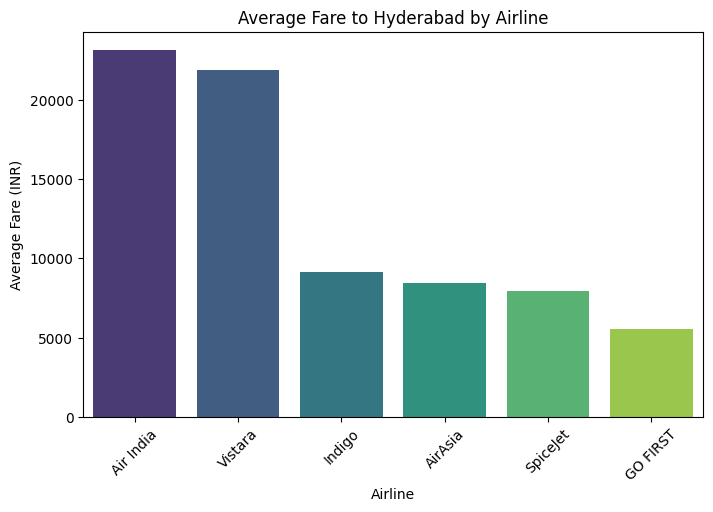

In [ ]:
# Your code here
#  Filter flights to Hyderabad
hyd_flights = df_merged[df_merged['Destination'] == 'Hyderabad']

# Calculate average fare per airline
avg_fare_hyd = hyd_flights.groupby('Airline')['Fare (Rupees)'].mean().sort_values(ascending=False)

fare_range = hyd_flights['Fare (Rupees)'].max() - hyd_flights['Fare (Rupees)'].min()
print("Fare range:", fare_range)
#  Plot bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=avg_fare_hyd.index, y=avg_fare_hyd.values, palette="viridis")
plt.title("Average Fare to Hyderabad by Airline")
plt.ylabel("Average Fare (INR)")
plt.xlabel("Airline")
plt.xticks(rotation=45)
plt.show()

**9. Plot a line chart showing how average Economy fares vary by days before departure for non-stop Indigo airline flights to Hyderabad that depart between 6 AM and 6 PM on weekdays**

Absolute difference: 646.333333333333


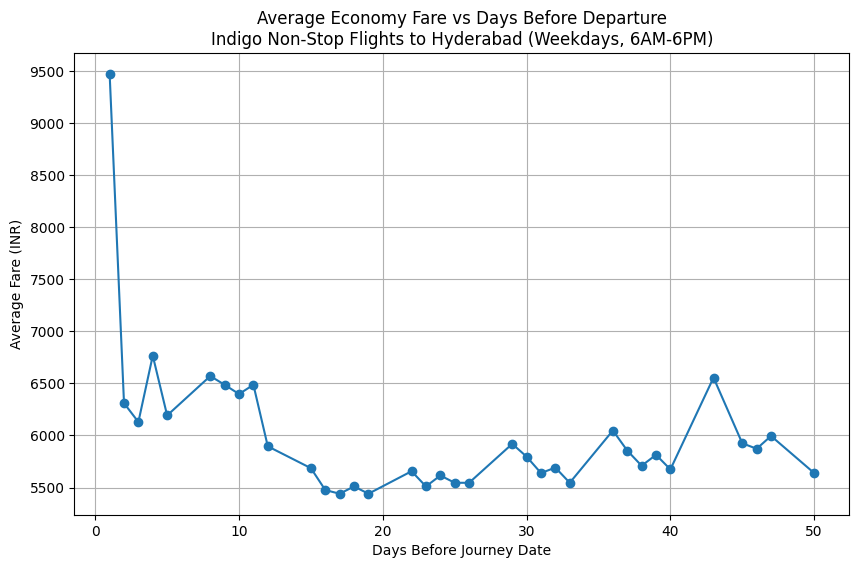

In [ ]:
# Your code here
# Filter the dataset
subset = df_merged[
    (df_merged['Airline'] == 'Indigo') &
    (df_merged['Destination'] == 'Hyderabad') &
    (df_merged['Class'] == 'Economy') &
    (df_merged['Number Of Stops'] == 0) &  # non-stop
    (df_merged['Departure'].isin(['6 AM - 12 PM', '12 PM - 6 PM'])) &  # 6AM-6PM
    (df_merged['Journey Day'].isin(['Monday','Tuesday','Wednesday','Thursday','Friday']))  # weekdays
]


# Group by Days Before Journey Date and calculate average fare
avg_fare_by_days = subset.groupby('Days Before Journey Date')['Fare (Rupees)'].mean().sort_index()
diff = abs(avg_fare_by_days.get(25, None) - avg_fare_by_days.get(5, None))
print(f"Absolute difference: {diff}")
# Plot line chart
plt.figure(figsize=(10,6))
plt.plot(avg_fare_by_days.index, avg_fare_by_days.values, marker='o')
plt.title("Average Economy Fare vs Days Before Departure\nIndigo Non-Stop Flights to Hyderabad (Weekdays, 6AM-6PM)")
plt.xlabel("Days Before Journey Date")
plt.ylabel("Average Fare (INR)")
plt.grid(True)
plt.show()

**10. Determine how prices vary by departure time for flights to the most common flying destination**

Most common destination: Mumbai
Departure
12 PM - 6 PM    22231.592365
6 AM - 12 PM    20345.863409
After 6 PM      16725.346692
Before 6 AM     16275.180225
Name: Fare (Rupees), dtype: float64


/tmp/ipython-input-2560702145.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_fare_by_departure.index, y=avg_fare_by_departure.values, palette="coolwarm")


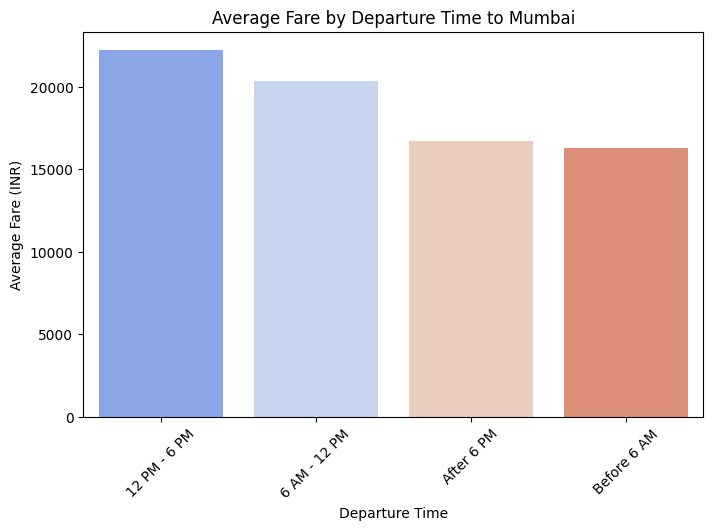

In [ ]:
# Your code here
# Count flights per destination
destination_counts = df_merged['Destination'].value_counts()

# Most common destination
most_common_dest = destination_counts.idxmax()
print("Most common destination:", most_common_dest)
dest_flights = df_merged[df_merged['Destination'] == most_common_dest]
avg_fare_by_departure = dest_flights.groupby('Departure')['Fare (Rupees)'].mean().sort_index()
print(avg_fare_by_departure)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=avg_fare_by_departure.index, y=avg_fare_by_departure.values, palette="coolwarm")
plt.title(f"Average Fare by Departure Time to {most_common_dest}")
plt.xlabel("Departure Time")
plt.ylabel("Average Fare (INR)")
plt.xticks(rotation=45)
plt.show()


**11. Standardize the numerical variables (excep Fare) using Mean Normalization***

*Hint: the formula for mean normalization is x minus the mean divided by the maximum value minus the minimum value for a column, where x is a particular value within the column*

In [ ]:
# Your code here
# Select numerical columns except 'Fare (Rupees)'
numerical_cols = df_merged.select_dtypes(include='number').columns.tolist()
numerical_cols.remove('Fare (Rupees)')  # exclude Fare

# Apply mean normalization
for col in numerical_cols:
    col_mean = df_merged[col].mean()
    col_max = df_merged[col].max()
    col_min = df_merged[col].min()
    df_merged[col + '_norm'] = (df_merged[col] - col_mean) / (col_max - col_min)

# Check the first few rows
df_merged[numerical_cols + [c+'_norm' for c in numerical_cols]].head()


,Flight ID,Number Of Stops,Duration (Hours),Year_x,Month_x,Day_x,Days Before Journey Date,Fare (GBP),Year_y,Month_y,...,Number Of Stops_norm,Duration (Hours)_norm,Year_x_norm,Month_x_norm,Day_x_norm,Days Before Journey Date_norm,Fare (GBP)_norm,Year_y_norm,Month_y_norm,Day_y_norm
0,1,1,14.5833,2023,3,6,50,98.40,2023,3,...,0.047884,0.079549,NaN,0.595313,-0.334498,0.494746,-0.088488,NaN,0.595313,-0.334498
1,2,1,15.2500,2023,3,6,50,98.40,2023,3,...,0.047884,0.095614,NaN,0.595313,-0.334498,0.494746,-0.088488,NaN,0.595313,-0.334498
2,3,1,13.4167,2023,1,16,1,116.25,2023,1,...,0.047884,0.051438,NaN,-0.404687,-0.001165,-0.505254,-0.073726,NaN,-0.404687,-0.001165
3,4,1,16.9167,2023,1,23,8,99.09,2023,1,...,0.047884,0.135775,NaN,-0.404687,0.232169,-0.362396,-0.087917,NaN,-0.404687,0.232169
4,5,1,14.3333,2023,1,30,15,88.95,2023,1,...,0.047884,0.073525,NaN,-0.404687,0.465502,-0.219539,-0.096303,NaN,-0.404687,0.465502


**12. Calculate the correlation matrix between all numerical variables in the dataset except Fare**

In [ ]:
# Your code here
# Select numerical columns
numerical_cols = df_merged.select_dtypes(include='number').columns.tolist()

# Exclude 'Fare (Rupees)'
if 'Fare (Rupees)' in numerical_cols:
    numerical_cols.remove('Fare (Rupees)')

# Calculate correlation matrix
correlation_matrix = df_merged[numerical_cols].corr()

# Display the correlation matrix
print(correlation_matrix)


                               Flight ID  Number Of Stops  Duration (Hours)  \
Flight ID                       1.000000        -0.045273         -0.066973   
Number Of Stops                -0.045273         1.000000          0.588437   
Duration (Hours)               -0.066973         0.588437          1.000000   
Year_x                               NaN              NaN               NaN   
Month_x                         0.060203        -0.015996         -0.046793   
Day_x                          -0.003796         0.012118          0.024785   
Days Before Journey Date        0.077807        -0.013473         -0.046886   
Fare (GBP)                      0.157478         0.142801          0.161973   
Year_y                               NaN              NaN               NaN   
Month_y                         0.060203        -0.015996         -0.046793   
Day_y                          -0.003796         0.012118          0.024785   
Flight ID_norm                  1.000000        -0.0

**13. Encode the categorical variables (Journey Day, Airline, Class, Departure, Destination) using one-hot encoding**

In [ ]:
# Your code here
# List of categorical columns to encode
categorical_cols = ['Journey Day', 'Airline', 'Class', 'Departure', 'Destination']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_merged, columns=categorical_cols, drop_first=False)

# Check the first few rows
print(df_encoded.head(5))


   Flight ID Journey Date Flight Number Origin  Number Of Stops      Arrival  \
0          1   2023-03-06        UK-927  Delhi                1  Before 6 AM   
1          2   2023-03-06        UK-963  Delhi                1  Before 6 AM   
2          3   2023-01-16        AI-885  Delhi                1  Before 6 AM   
3          4   2023-01-23        AI-560  Delhi                1  Before 6 AM   
4          5   2023-01-30        AI-542  Delhi                1  Before 6 AM   

   Duration (Hours)  Year_x  Month_x  Day_x  ...  Departure_12 PM - 6 PM  \
0           14.5833    2023        3      6  ...                   False   
1           15.2500    2023        3      6  ...                   False   
2           13.4167    2023        1     16  ...                   False   
3           16.9167    2023        1     23  ...                   False   
4           14.3333    2023        1     30  ...                   False   

   Departure_6 AM - 12 PM  Departure_After 6 PM  Departure_Bef

**14. Create a multivariate regression model to predict the fare in Indian Rupees**

*Hint: use all the rows in the model, but be selective with the columns you decided to include; run a first pass using just the numerical and one-hot encoded columns as your independent variables*

In [ ]:
# Your code here
columns_to_exclude = ['Fare (Rupees)', 'Fare (GBP)', 'Flight ID', 'Flight Number', 'Journey Date', 'Origin', 'Arrival','Year_x', 'Year_y', 'Year_x_norm', 'Year_y_norm']

# 删除这些列
df_clean = df_encoded.drop(columns=columns_to_exclude)

# 确认剩余列
print(df_clean.columns)
X = df_encoded.drop(columns=columns_to_exclude)

# Keep only numeric columns (int, float, or boolean)
X = X.select_dtypes(include=['int64', 'float64', 'bool'])

# Convert boolean to float
X = X.astype(float)

# Target variable
y = df_encoded['Fare (Rupees)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# check top coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coef_df.sort_values(by='Coefficient', ascending=False).head(10))

Index(['Number Of Stops', 'Duration (Hours)', 'Month_x', 'Day_x',
       'Days Before Journey Date', 'Month_y', 'Day_y', 'Flight ID_norm',
       'Number Of Stops_norm', 'Duration (Hours)_norm', 'Month_x_norm',
       'Day_x_norm', 'Days Before Journey Date_norm', 'Fare (GBP)_norm',
       'Month_y_norm', 'Day_y_norm', 'Journey Day_Friday',
       'Journey Day_Monday', 'Journey Day_Saturday', 'Journey Day_Sunday',
       'Journey Day_Thursday', 'Journey Day_Tuesday', 'Journey Day_Wednesday',
       'Airline_Air India', 'Airline_AirAsia', 'Airline_AkasaAir',
       'Airline_AllianceAir', 'Airline_GO FIRST', 'Airline_Indigo',
       'Airline_SpiceJet', 'Airline_Vistara', 'Class_Business',
       'Class_Economy', 'Class_First', 'Class_Premium Economy',
       'Departure_12 PM - 6 PM', 'Departure_6 AM - 12 PM',
       'Departure_After 6 PM', 'Departure_Before 6 AM',
       'Destination_Ahmedabad', 'Destination_Bangalore', 'Destination_Chennai',
       'Destination_Hyderabad', 'Destination_

**15. Determine the coefficients and p-values of the input variables in the model**

In [ ]:
# Your code here
import statsmodels.api as sm

# Prepare features (exclude target and any derived features like Fare (GBP)_norm)
cols_to_exclude = ['Fare (Rupees)', 'Fare (GBP)', 'Fare (GBP)_norm', 'Flight ID', 'Flight Number', 'Journey Date']
X = df_encoded.drop(columns=cols_to_exclude)

# Keep only numeric/boolean columns
X = X.select_dtypes(include=['int64', 'float64', 'bool']).astype(float)

# Target
y = df_clean['Fare (GBP)_norm']

# Add constant term for intercept
X = sm.add_constant(X)

# Fit OLS regression
model = sm.OLS(y, X).fit()

# Get summary (includes coefficients, p-values, R-squared, etc.)
summary = model.summary()
print(summary)

# Optional: just coefficients and p-values as a dataframe
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.params,
    'P-value': model.pvalues
}).sort_values(by='P-value')
print(coef_df.head(10))  # top 10 by significance


MissingDataError: exog contains inf or nans

In [ ]:
print(df_clean.columns)

Index(['Number Of Stops', 'Duration (Hours)', 'Month_x', 'Day_x',
       'Days Before Journey Date', 'Month_y', 'Day_y', 'Flight ID_norm',
       'Number Of Stops_norm', 'Duration (Hours)_norm', 'Month_x_norm',
       'Day_x_norm', 'Days Before Journey Date_norm', 'Fare (GBP)_norm',
       'Month_y_norm', 'Day_y_norm', 'Journey Day_Friday',
       'Journey Day_Monday', 'Journey Day_Saturday', 'Journey Day_Sunday',
       'Journey Day_Thursday', 'Journey Day_Tuesday', 'Journey Day_Wednesday',
       'Airline_Air India', 'Airline_AirAsia', 'Airline_AkasaAir',
       'Airline_AllianceAir', 'Airline_GO FIRST', 'Airline_Indigo',
       'Airline_SpiceJet', 'Airline_Vistara', 'Class_Business',
       'Class_Economy', 'Class_First', 'Class_Premium Economy',
       'Departure_12 PM - 6 PM', 'Departure_6 AM - 12 PM',
       'Departure_After 6 PM', 'Departure_Before 6 AM',
       'Destination_Ahmedabad', 'Destination_Bangalore', 'Destination_Chennai',
       'Destination_Hyderabad', 'Destination_

**16. Exclude insignificant variables (if any) and re-create the model**

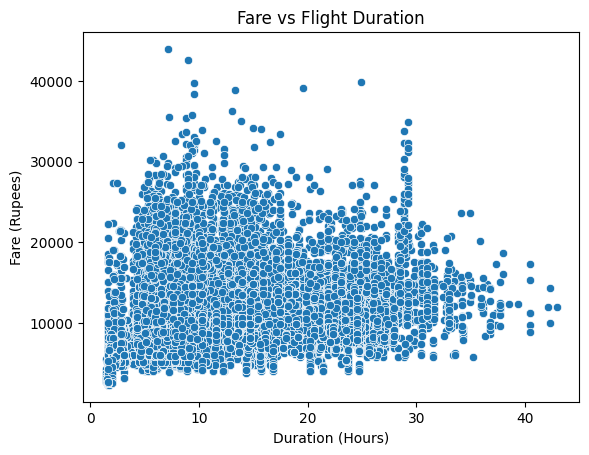

                  Duration (Hours)  Fare (Rupees)
Duration (Hours)          1.000000       0.300374
Fare (Rupees)             0.300374       1.000000


In [ ]:
# Your code here
import seaborn as sns
import matplotlib.pyplot as plt


df_economy = df_merged[df_merged['Class'] == 'Economy']


sns.scatterplot(data=df_economy, x='Duration (Hours)', y='Fare (Rupees)')
plt.title('Fare vs Flight Duration')
plt.show()


print(df_economy[['Duration (Hours)', 'Fare (Rupees)']].corr())
